# ML-07 — Baseline Action Score and Top-20 Review

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/maalaaikaa/flyrank-ml-internship/blob/main/work/notebooks/w04_baseline_score.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My rule and its reason codes

### My rule and its reason codes

The baseline action score prioritizes content for review using observable search and engagement signals available before the prediction point.

A content item receives a higher score when it has weaker search visibility, weaker click-through performance, and/or weak engagement. Search volume is also considered so that pages with meaningful search demand can receive more attention.

The score is a simple decision-support rule, not a prediction of future performance.

Reason codes explain why an item received a high score:

- `LOW_CTR` — click-through rate is relatively low.
- `POOR_POSITION` — average search position is relatively weak.
- `LOW_ENGAGEMENT` — engagement rate is relatively low.
- `HIGH_DEMAND` — search volume is relatively high, so the content has greater potential value to review.
- `MULTI_SIGNAL` — multiple negative signals are present.

The baseline does not use `trend_pct` or `trend_direction`, because these are target-related and would leak the outcome into the action score.

## 2. Build the ranked queue (writes the CSV)



In [11]:
import pandas as pd

# Load the dataset from GitHub
url = "https://raw.githubusercontent.com/maalaaikaa/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

# --------------------------------------------------
# 1. Required columns
# --------------------------------------------------

required_cols = [
    "content_id",
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate"
]

missing_required = [
    col for col in required_cols
    if col not in df.columns
]

if missing_required:
    raise ValueError(
        f"Required columns are missing: {missing_required}"
    )

# Work on a copy
score_df = df.copy()

# --------------------------------------------------
# 2. Fill missing values using dataset medians
# --------------------------------------------------

score_features = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate"
]

for col in score_features:
    score_df[col] = score_df[col].fillna(
        score_df[col].median()
    )

# --------------------------------------------------
# 3. Convert each signal to a percentile
# --------------------------------------------------

# Low CTR = higher priority
score_df["low_ctr_score"] = (
    1 - score_df["ctr"].rank(pct=True)
)

# Worse / larger average position = higher priority
score_df["poor_position_score"] = (
    score_df["avg_position"].rank(pct=True)
)

# Low engagement = higher priority
score_df["low_engagement_score"] = (
    1 - score_df["engagement_rate"].rank(pct=True)
)

# High search volume = higher potential value
score_df["high_demand_score"] = (
    score_df["search_volume"].rank(pct=True)
)

# --------------------------------------------------
# 4. Baseline action score
# --------------------------------------------------

score_df["action_score"] = (
    0.30 * score_df["low_ctr_score"]
    + 0.30 * score_df["poor_position_score"]
    + 0.25 * score_df["low_engagement_score"]
    + 0.15 * score_df["high_demand_score"]
)

# --------------------------------------------------
# 5. Rank all content
# --------------------------------------------------

score_df = score_df.sort_values(
    "action_score",
    ascending=False
).reset_index(drop=True)

score_df["rank"] = np.arange(1, len(score_df) + 1)

# --------------------------------------------------
# 6. Create reason codes
# --------------------------------------------------

reason_codes = []

for _, row in score_df.iterrows():

    reasons = []

    if row["low_ctr_score"] >= 0.75:
        reasons.append("LOW_CTR")

    if row["poor_position_score"] >= 0.75:
        reasons.append("POOR_POSITION")

    if row["low_engagement_score"] >= 0.75:
        reasons.append("LOW_ENGAGEMENT")

    if row["high_demand_score"] >= 0.75:
        reasons.append("HIGH_DEMAND")

    if len(reasons) >= 2:
        reasons.insert(0, "MULTI_SIGNAL")

    if not reasons:
        reasons.append("GENERAL_REVIEW")

    reason_codes.append("|".join(reasons))

score_df["reason_code"] = reason_codes

# --------------------------------------------------
# 7. Action
# --------------------------------------------------

score_df["action"] = np.where(
    score_df["rank"] <= 20,
    "REVIEW",
    "MONITOR"
)

# --------------------------------------------------
# 8. Confidence note
# --------------------------------------------------

score_df["confidence_note"] = np.where(
    score_df["reason_code"].str.contains("MULTI_SIGNAL"),
    "Multiple observed signals support review.",
    "Single or limited observed signals support review."
)

# --------------------------------------------------
# 9. Save the ranked queue
# --------------------------------------------------

output_dir = Path("work/outputs")
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / "baseline_action_score.csv"

output_columns = [
    "rank",
    "content_id",
    "action",
    "action_score",
    "reason_code",
    "confidence_note",
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate"
]

score_df[output_columns].to_csv(
    output_path,
    index=False
)

print("Baseline queue created.")
print("Output:", output_path)
print("Rows:", len(score_df))
print("Top 20 rows:", min(20, len(score_df)))

Baseline queue created.
Output: work/outputs/baseline_action_score.csv
Rows: 30000
Top 20 rows: 20


In [13]:
# Inspect the top 20 ranked items

top20 = score_df.head(20)[
    [
        "rank",
        "content_id",
        "action",
        "action_score",
        "reason_code",
        "confidence_note",
        "search_volume",
        "ctr",
        "avg_position",
        "engagement_rate"
    ]
]

top20

,rank,content_id,action,action_score,reason_code,confidence_note,search_volume,ctr,avg_position,engagement_rate
0,1,content_661e1745db72,REVIEW,0.842190,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,2400.0,0.0,245.0,0.0
1,2,content_3921a7d7066d,REVIEW,0.841160,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,5400.0,0.0,74.1,0.0
2,3,content_2ea49fcfdf36,REVIEW,0.841108,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,2900.0,0.0,77.3,0.0
3,4,content_c41622fe1359,REVIEW,0.840202,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,1300.0,0.0,80.3,0.0
4,5,content_e34fe8c07fa2,REVIEW,0.839722,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,3600.0,0.0,69.8,0.0
5,6,content_4983b29e8a51,REVIEW,0.839633,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,1300.0,0.0,76.2,0.0
6,7,content_8ec653ac9eda,REVIEW,0.839222,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,1000.0,0.0,76.4,0.0
7,8,content_83e3da1394ac,REVIEW,0.839152,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,49500.0,0.0,65.5,0.0
8,9,content_a11501e6e45d,REVIEW,0.838690,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,5400.0,0.0,66.0,0.0
9,10,content_c5b822611dc0,REVIEW,0.838540,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,880.0,0.0,75.5,0.0


## 3. Top-20 review

### Top-20 review

The top 20 items are the highest-ranked content items under the baseline action rule.

Each item receives:
- an action (`REVIEW`);
- one or more reason codes;
- a confidence note based on the number of supporting signals;
- a note describing what could make the recommendation wrong.

The recommendations are decision-support rather than automatic refresh decisions. A high score does not prove that a page is declining or that a refresh will improve performance.

In [14]:
# Generate the Top-20 review table

review = score_df.head(20).copy()

review["what_would_make_it_wrong"] = (
    "The observed signals may not reflect the current content state, "
    "measurement windows may differ, or the content may have valid "
    "business/editorial reasons for its current performance."
)

review_columns = [
    "rank",
    "content_id",
    "action",
    "reason_code",
    "confidence_note",
    "what_would_make_it_wrong",
    "action_score"
]

review[review_columns]

,rank,content_id,action,reason_code,confidence_note,what_would_make_it_wrong,action_score
0,1,content_661e1745db72,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.842190
1,2,content_3921a7d7066d,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.841160
2,3,content_2ea49fcfdf36,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.841108
3,4,content_c41622fe1359,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.840202
4,5,content_e34fe8c07fa2,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.839722
5,6,content_4983b29e8a51,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.839633
6,7,content_8ec653ac9eda,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.839222
7,8,content_83e3da1394ac,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.839152
8,9,content_a11501e6e45d,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.838690
9,10,content_c5b822611dc0,REVIEW,MULTI_SIGNAL|LOW_CTR|POOR_POSITION|HIGH_DEMAND,Multiple observed signals support review.,The observed signals may not reflect the curre...,0.838540


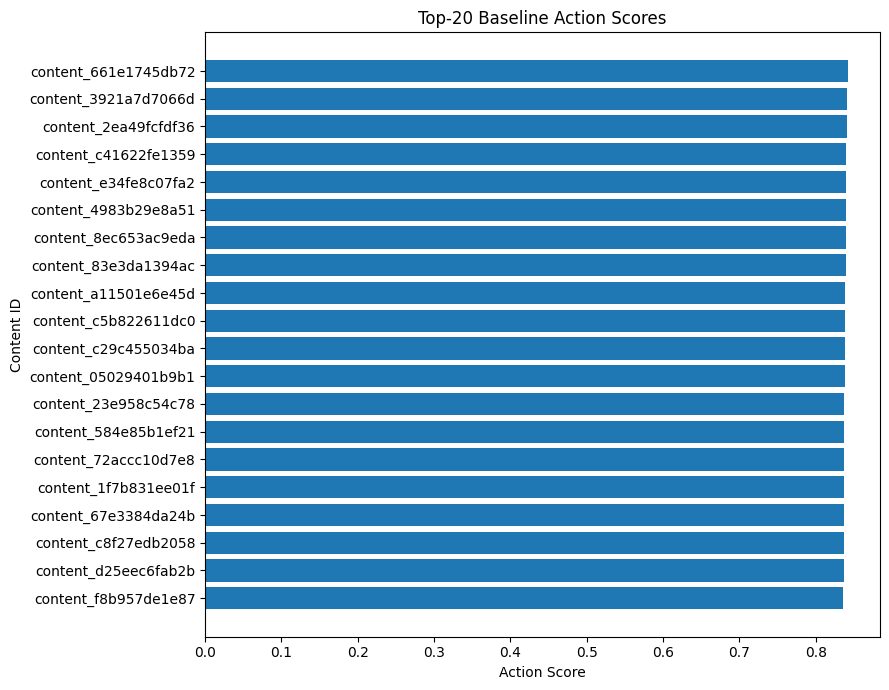

In [15]:
import matplotlib.pyplot as plt

top20_plot = score_df.head(20).sort_values(
    "action_score",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top20_plot["content_id"].astype(str),
    top20_plot["action_score"]
)

plt.title("Top-20 Baseline Action Scores")
plt.xlabel("Action Score")
plt.ylabel("Content ID")

plt.tight_layout()
plt.show()

## 4. Weak picks + leakage check


A weak pick is an item that receives a high baseline score but does not have a clear or useful reason for content review. For example, a page may rank highly because of one weak metric even though its other signals are relatively strong.

The baseline is intentionally simple, so these cases are expected. They should be reviewed by a content team rather than treated as automatic refresh recommendations.

The leakage check confirms that the baseline score does not use `trend_pct` or `trend_direction`. It also checks that identifier fields and known duplicate/tier fields are not used in the scoring formula.

In [16]:
# Identify potentially weak picks
# These are high-ranked items supported by only one reason code.

weak_picks = score_df[
    (score_df["rank"] <= 20)
    &
    (~score_df["reason_code"].str.contains("MULTI_SIGNAL"))
].copy()

print("Potentially weak Top-20 picks:")
print(
    weak_picks[
        [
            "rank",
            "content_id",
            "action_score",
            "reason_code",
            "search_volume",
            "ctr",
            "avg_position",
            "engagement_rate"
        ]
    ]
)

Potentially weak Top-20 picks:
Empty DataFrame
Columns: [rank, content_id, action_score, reason_code, search_volume, ctr, avg_position, engagement_rate]
Index: []


In [17]:
# --------------------------------------------------
# Leakage / excluded-field check
# --------------------------------------------------

leakage_fields = [
    "trend_pct",
    "trend_direction"
]

identifier_fields = [
    "content_id",
    "client_id"
]

known_excluded_fields = [
    "char_count_tier",
    "impression_tier",
    "position_tier"
]

# Fields actually used to calculate the score
scoring_features = [
    "search_volume",
    "ctr",
    "avg_position",
    "engagement_rate"
]

# Confirm target fields are not scoring features
for col in leakage_fields:
    assert col not in scoring_features, (
        f"Leakage detected: {col} is being used as a scoring feature."
    )

# Confirm identifiers are not scoring features
for col in identifier_fields:
    assert col not in scoring_features, (
        f"Identifier leakage detected: {col} is being used as a scoring feature."
    )

# Confirm known excluded fields are not scoring features
for col in known_excluded_fields:
    assert col not in scoring_features, (
        f"Excluded field is being used: {col}"
    )

print("✓ trend_pct is not used")
print("✓ trend_direction is not used")
print("✓ content_id is not used as a scoring feature")
print("✓ client_id is not used as a scoring feature")
print("✓ known tier fields are not used")
print("✓ No target leakage detected in the baseline scoring formula")

✓ trend_pct is not used
✓ trend_direction is not used
✓ content_id is not used as a scoring feature
✓ client_id is not used as a scoring feature
✓ known tier fields are not used
✓ No target leakage detected in the baseline scoring formula


In [18]:
# Final scoring formula audit

print("Scoring features:")
for feature in scoring_features:
    print("-", feature)

print("\nTarget:")
print("-", "trend_pct")

print("\nTarget-derived field excluded:")
print("-", "trend_direction")

print(
    "\nThe baseline uses only observed search/content/engagement "
    "signals and does not use the target."
)

Scoring features:
- search_volume
- ctr
- avg_position
- engagement_rate

Target:
- trend_pct

Target-derived field excluded:
- trend_direction

The baseline uses only observed search/content/engagement signals and does not use the target.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.